# Model Training

## Imports of all the required libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import os
import sys
import matplotlib.pyplot as plt

In [2]:
sys.path.append(os.path.abspath(os.path.join('..')))

In [3]:
# Execution of Model Classes from models.ipynb where all the models are defined
%run models.ipynb

## Basic Parameter Definition

In [4]:
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


## Data Transformation and Augmentation

In [5]:
# Simple Transformation for Baseline Model
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) # --- Attempt 1
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # --- Attempt 2: Prefered Normalization
])

# Data Augmentation for Further Models (Improved and Pre-trained)
# - Random Horizontal Flip
# - Random Vertical Flip
# - Uniform Random Rotation from -90 to 90 degree
augmented_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

The pixel values are initially normalized to mean 0.5 and standard deviation 0.5 for all three RGB channels. 
Since the initial normalization Overfit with huge margins, the color channels are normalized with ImageNet Specific Normalization:
Mean: 0.485, 0.456, 0.406 (R, G, B)
Standard Deviation: 0.229, 0.224, 0.225 (R, G, B) 

## Data Loading Pipeline

In [6]:
# Initialize standard and augmented DataLoaders for model training, validation, and testing
simple_train_set = datasets.ImageFolder(root='../../data/processed_data/train', transform=simple_transform)
simple_val_set = datasets.ImageFolder(root='../../data/processed_data/val', transform=simple_transform)
augmented_train_set = datasets.ImageFolder(root='../../data/processed_data/train', transform=augmented_transform)
augmented_val_set = datasets.ImageFolder(root='../../data/processed_data/val', transform=augmented_transform)

test_set = datasets.ImageFolder(root='../../data/processed_data/test')

simple_train_loader = DataLoader(simple_train_set, batch_size=BATCH_SIZE, shuffle=True)
simple_val_loader = DataLoader(simple_val_set, batch_size=BATCH_SIZE, shuffle=False)

augmented_train_loader = DataLoader(augmented_train_set, batch_size=BATCH_SIZE, shuffle=True)
augmented_val_loader = DataLoader(augmented_val_set, batch_size=BATCH_SIZE, shuffle=False)

test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

## Model Training Loop

In [7]:
# Define Traning Logic
def train_model(model, model_name, train_loader, val_loader, epochs, lr, isScheduler=False, optimizer_name="adam"):
    model = model.to(DEVICE) # Move model to GPU or CPU 
    criterion = nn.CrossEntropyLoss() # Define a Loss Function
    
    # Define an optimizer
    optimizer = None
    if (optimizer_name == "adam"):
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr) 
    elif (optimizer_name == "rmsp"):
        optimizer = optim.RMSprop(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, alpha=0.99) 
    elif (optimizer_name == "sgd"):
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")
        
    scheduler = None
    if (isScheduler):
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    
    best_acc = 0.0
    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        running_loss = 0.0
        
        train_bar = tqdm(train_loader, desc=f"{model_name} - Epoch {epoch+1}/{epochs}")
        
        for images, labels in train_bar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            # Backpropagation
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            train_bar.set_postfix(loss=loss.item())

        avg_loss = running_loss / len(train_loader)
        
        # --- VALIDATION ---
        model.eval()
        correct, total = 0, 0

        val_bar = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{epochs}] Val", unit="batch", leave=False)
        
        with torch.no_grad():
            for images, labels in val_bar:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_acc = 100 * correct / total

        if scheduler is not None:
            scheduler.step(val_acc)
        
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Result: Loss {avg_loss:.4f} | Val Acc {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"{model_name}.pth")
            print(f"Saved Best {model_name} with {val_acc:.2f}% accuracy")
            
    return history

In [8]:
def plot_learning_curves(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Training Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'r-o', label='Training Loss')
    plt.title(f'{model_name}: Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    
    # Plot 2: Validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_acc'], 'b-o', label='Val Accuracy')
    plt.title(f'{model_name}: Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

### Training Baseline Model

In [9]:
model1 = BaselineModel()

total_params = sum(p.numel() for p in model1.parameters())
trainable_params = sum(p.numel() for p in model1.parameters() if p.requires_grad)

print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Non-Trainable:        {total_params - trainable_params:,}")

Total Parameters:     58,322,314
Trainable Parameters: 58,322,314
Non-Trainable:        0


In [10]:
# history1 = train_model(model1, "model1_baseline", simple_train_loader, simple_val_loader, epochs = 15, lr = 0.001, optimizer_name = "adam") #--- Attempt 1 with Generic Pixel Normalization
# history1 = train_model(model1, "model1_baseline", simple_train_loader, simple_val_loader, epochs = 15, lr = 0.0001, optimizer_name = "adam") #--- Attempt 2: with Generic Pixel Normalization
# history1 = train_model(model1, "model1_baseline", simple_train_loader, simple_val_loader, epochs = 15, lr = 0.0001, optimizer_name = "rmsp") #--- Attempt 3: with Generic Pixel Normalization
# history1 = train_model(model1, "model1_baseline", simple_train_loader, simple_val_loader, epochs = 15, lr = 0.01, optimizer_name = "sgd") #--- Attempt 4: with Generic Pixel Normalization
# history1 = train_model(model1, "model1_baseline", simple_train_loader, simple_val_loader, epochs = 15, lr = 0.01, optimizer_name = "sgd" ) #--- Attempt 5: with ImageNet Pixel Normalization 
history1 = train_model(model1, "model1_baseline", simple_train_loader, simple_val_loader, epochs = 15, lr = 0.0001, optimizer_name = "adam" ) #--- Attempt 5: with ImageNet Pixel Normalization : Choosen Parameter 

model1_baseline - Epoch 1/15: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:36<00:00,  8.21it/s, loss=0.82]
                                                                                                                                                                                                                              

Result: Loss 1.3380 | Val Acc 69.58%
Saved Best model1_baseline with 69.58% accuracy


model1_baseline - Epoch 2/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:37<00:00,  7.87it/s, loss=0.812]
                                                                                                                                                                                                                              

Result: Loss 0.7964 | Val Acc 75.88%
Saved Best model1_baseline with 75.88% accuracy


model1_baseline - Epoch 3/15: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:36<00:00,  8.07it/s, loss=0.61]
                                                                                                                                                                                                                              

...

Result: Loss 0.1555 | Val Acc 93.53%


model1_baseline - Epoch 14/15: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:35<00:00,  8.39it/s, loss=0.0552]
                                                                                                                                                                                                                              

Result: Loss 0.1443 | Val Acc 91.85%


model1_baseline - Epoch 15/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:36<00:00,  8.03it/s, loss=0.12]
                                                                                                                                                                                                                              

Result: Loss 0.1502 | Val Acc 93.41%


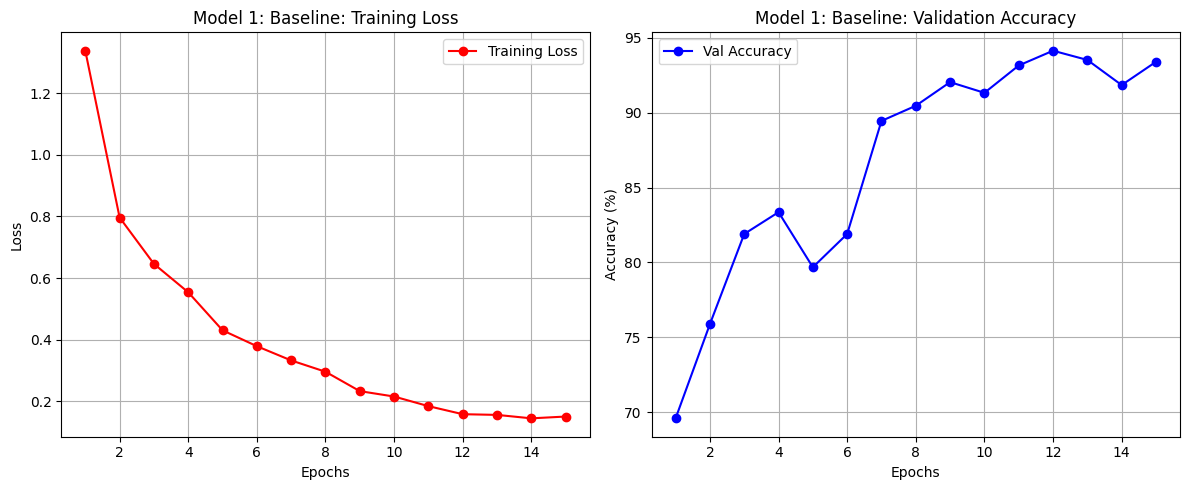

In [11]:
plot_learning_curves(history1, "Model 1: Baseline")

### Training Improved Model

Added Batch Normalization after every convolution layer, the dataset is Augmented with ImageNet Specific Pixel Normalization

In [12]:
model2 = Improved_Model()

total_params = sum(p.numel() for p in model2.parameters())
trainable_params = sum(p.numel() for p in model2.parameters() if p.requires_grad)

print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Non-Trainable:        {total_params - trainable_params:,}")

Total Parameters:     57,801,162
Trainable Parameters: 57,801,162
Non-Trainable:        0


In [13]:
# history2 = train_model(model2, "model2_improved", augmented_train_loader, augmented_val_loader, epochs = 25, lr = 0.0001, isScheduler=False, optimizer_name="adam") # --- Attempt 1
history2 = train_model(model2, "model2_improved", augmented_train_loader, augmented_val_loader, epochs = 25, lr = 0.0001, isScheduler=True, optimizer_name="adam") # --- Attempt 2: Choosen Parameter
# history2 = train_model(model2, "model2_improved", augmented_train_loader, augmented_val_loader, epochs = 25, lr = 0.01, isScheduler=True, optimizer_name="adam") # --- Attempt 3
# history2 = train_model(model2, "model2_improved", augmented_train_loader, augmented_val_loader, epochs = 50, lr = 0.0001, isScheduler=True, optimizer_name="adam") # --- Attempt 4
# history2 = train_model(model2, "model2_improved", augmented_train_loader, augmented_val_loader, epochs = 50, lr = 0.00005, isScheduler=True) # --- Attempt 5

model2_improved - Epoch 1/25: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:36<00:00,  8.22it/s, loss=1.07]
                                                                                                                                                                                                                              

Result: Loss 0.8845 | Val Acc 72.69%
Saved Best model2_improved with 72.69% accuracy


model2_improved - Epoch 2/25: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:34<00:00,  8.60it/s, loss=0.878]
                                                                                                                                                                                                                              

Result: Loss 0.6400 | Val Acc 68.07%


model2_improved - Epoch 3/25: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:35<00:00,  8.31it/s, loss=0.649]
                                                                                                                                                                                                                              

...

Result: Loss 0.1250 | Val Acc 94.05%


model2_improved - Epoch 24/25: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:40<00:00,  7.38it/s, loss=0.0633]
                                                                                                                                                                                                                              

Result: Loss 0.1154 | Val Acc 95.58%
Saved Best model2_improved with 95.58% accuracy


model2_improved - Epoch 25/25: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:35<00:00,  8.35it/s, loss=0.176]
                                                                                                                                                                                                                              

Result: Loss 0.1207 | Val Acc 96.07%
Saved Best model2_improved with 96.07% accuracy


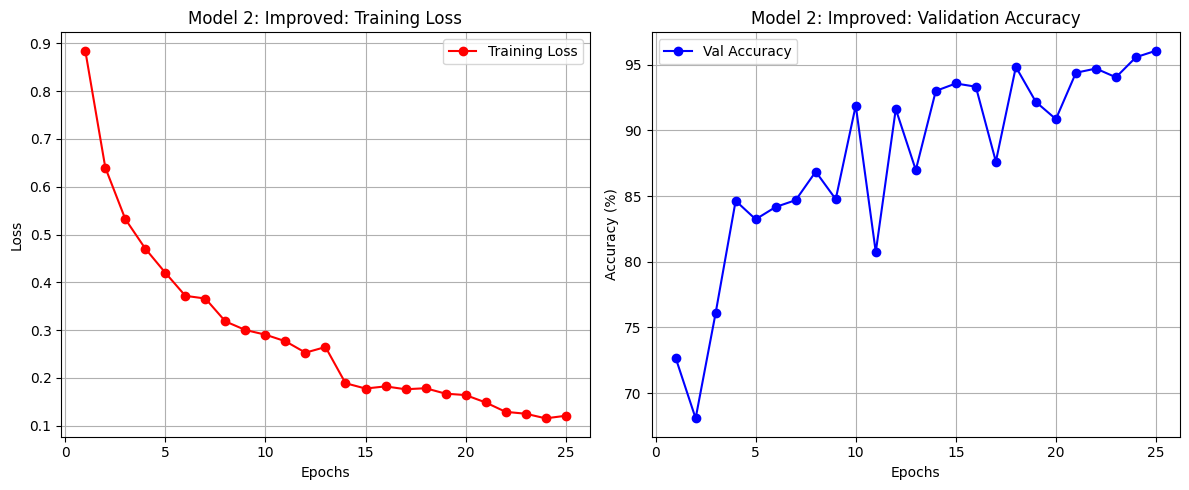

In [14]:
plot_learning_curves(history2, "Model 2: Improved")

### Training Pre-Trained Model

Fine-Tuning of ResNet-50 with Augmented Data with ImageNet Specific Pixel Normalization

In [15]:
model3 = get_resnet_model()

total_params = sum(p.numel() for p in model3.parameters())
trainable_params = sum(p.numel() for p in model3.parameters() if p.requires_grad)

print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Non-Trainable:        {total_params - trainable_params:,}")

Total Parameters:     23,528,522
Trainable Parameters: 14,985,226
Non-Trainable:        8,543,296


In [16]:
# history3 = train_model(model3, "model3_pretrained", augmented_train_loader, augmented_val_loader, epochs = 15, lr = 0.0001, isScheduler=False) # --- Attempt 1
# history3 = train_model(model3, "model3_pretrained", augmented_train_loader, augmented_val_loader, epochs = 15, lr = 0.0001, isScheduler=True) # --- Attempt 2
# history3 = train_model(model3, "model3_pretrained", augmented_train_loader, augmented_val_loader, epochs = 15, lr = 0.01, isScheduler=True) # --- Attempt 3
history3 = train_model(model3, "model3_pretrained", augmented_train_loader, augmented_val_loader, epochs = 15, lr = 0.001, isScheduler=True) # --- Attempt 4: Choosen Parameter
# history3 = train_model(model3, "model3_pretrained", augmented_train_loader, augmented_val_loader, epochs = 15, lr = 0.00005, isScheduler=True) # --- Attempt 5
# history3 = train_model(model3, "model3_pretrained", augmented_train_loader, augmented_val_loader, epochs = 50, lr = 0.001, isScheduler=True) # --- Attempt 6

model3_pretrained - Epoch 1/15: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [01:00<00:00,  4.87it/s, loss=0.421]
                                                                                                                                                                                                                              

Result: Loss 0.2582 | Val Acc 96.35%
Saved Best model3_pretrained with 96.35% accuracy


model3_pretrained - Epoch 2/15: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [01:02<00:00,  4.77it/s, loss=0.653]
                                                                                                                                                                                                                              

Result: Loss 0.1231 | Val Acc 97.23%
Saved Best model3_pretrained with 97.23% accuracy


model3_pretrained - Epoch 3/15: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [01:02<00:00,  4.77it/s, loss=0.0995]
                                                                                                                                                                                                                              

...

Result: Loss 0.0338 | Val Acc 98.59%
Saved Best model3_pretrained with 98.59% accuracy


model3_pretrained - Epoch 14/15: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [01:01<00:00,  4.78it/s, loss=0.0377]
                                                                                                                                                                                                                              

Result: Loss 0.0254 | Val Acc 98.30%


model3_pretrained - Epoch 15/15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [01:02<00:00,  4.75it/s, loss=0.00392]
                                                                                                                                                                                                                              

Result: Loss 0.0275 | Val Acc 98.42%


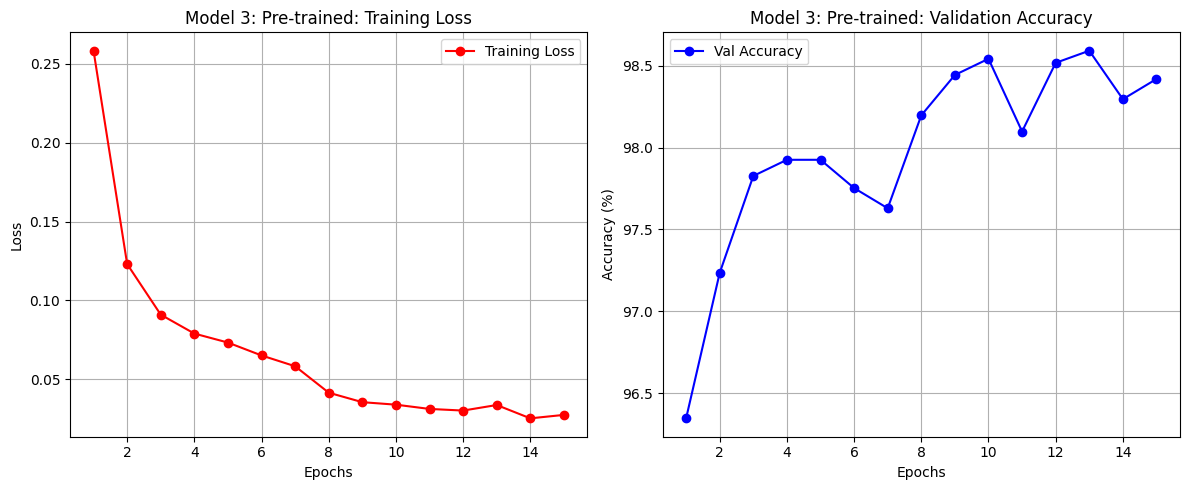

In [17]:
plot_learning_curves(history3, "Model 3: Pre-trained")

The evaluation of all the Three Choosen Models is available at evaluation.ipynb